# 🌌 Visualización de Universos Sintéticos - KineTopus Engine

Este notebook está diseñado para **auditar visual y estadísticamente** la generación de datos sintéticos en el `optimization_lab`.
Analizaremos por qué la simulación actual arrojó métricas de autocorrelación tan altas y cómo se comportan las velas sintéticas.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Configurar matplotlib para modo oscuro premium
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['grid.color'] = '#2c2c2c'

# Añadir la raíz del optimization_lab al path
sys.path.append(os.path.abspath('..'))

from core.ui.synthetic_generator import SyntheticMarketGenerator
from core.ui.market_loader import MarketLoader

In [ ]:
# 1. Instanciar el Generador y crear un Universo de 800 velas
generator = SyntheticMarketGenerator(base_ticker='BTC-USD')
df_synth = generator.generate_multiverse(num_candles=2000, mc_trajectories=100)

print("Estructura del DataFrame Sintético:")
print(df_synth.info())
print("\nPrimeras 5 velas:")
print(df_synth.head())

c:\Users\ussaa\AppData\Local\Programs\Python\Python314\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(
c:\Users\ussaa\AppData\Local\Programs\Python\Python314\Lib\site-packages\pysindy\optimizers\stlsq.py:234: UserWarning: Sparsity parameter is too big (0.05) and eliminated all coefficients
  warnings.warn(
c:\Users\ussaa\Documents\KineTopus Engine\optimization_lab\core\quant_engine\physics.py:210: RuntimeWarning: overflow encountered in exp
  det_price_path = (last_price * np.exp(cum_ret_det)).tolist()
c:\Users\ussaa\Documents\KineTopus Engine\optimization_lab\core\quant_engine\physics.py:210: RuntimeWarning: overflow encountered in multiply
  det_price_path = (last_price * np.exp(cum_ret_det)).tolist()


Estructura del DataFrame Sintético:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 800 entries, 2026-06-05 00:00:00+00:00 to 2028-08-12 00:00:00+00:00
Freq: D
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    800 non-null    float64
 1   High    800 non-null    float64
 2   Low     800 non-null    float64
 3   Close   800 non-null    float64
 4   Volume  800 non-null    float64
dtypes: float64(5)
memory usage: 37.5 KB
None

Primeras 5 velas:
                                   Open          High           Low  \
Date                                                                  
2026-06-05 00:00:00+00:00  63016.797191  63468.311633  62720.716213   
2026-06-06 00:00:00+00:00  62698.052081  62969.461146  62340.520032   
2026-06-07 00:00:00+00:00  62185.285090  62388.951315  61737.057340   
2026-06-08 00:00:00+00:00  62166.787270  62449.349769  61319.039518   
2026-06-09 00:00:00+00:00  62220.583769  62563.132472

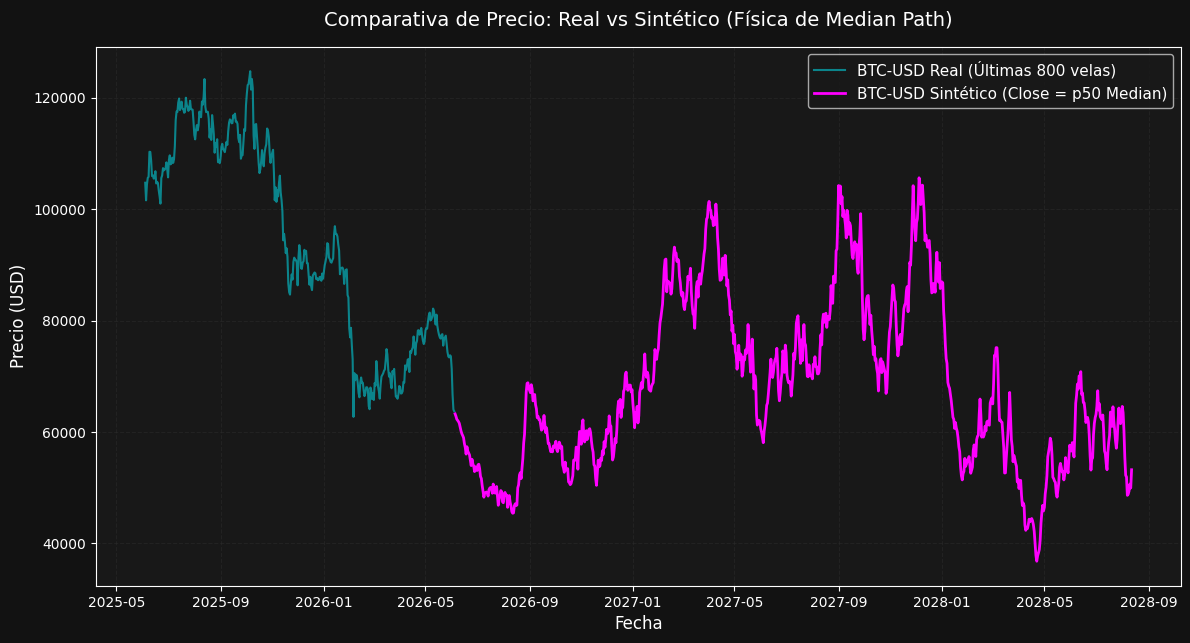

In [4]:
# 2. Cargar datos reales de referencia
df_real = MarketLoader.load_ticker_data('BTC-USD', period='1y', interval='1d')
if isinstance(df_real.columns, pd.MultiIndex):
    df_real.columns = df_real.columns.droplevel(1)

# Comparación visual de la trayectoria de precios
plt.figure(figsize=(14, 7))
plt.plot(df_real.index[-800:], df_real['Close'].iloc[-800:].values, label='BTC-USD Real (Últimas 800 velas)', color='#00f0ff', alpha=0.5)
plt.plot(df_synth.index, df_synth['Close'].values, label='BTC-USD Sintético (Close = p50 Median)', color='#ff00ff', linewidth=2)
plt.title('Comparativa de Precio: Real vs Sintético (Física de Median Path)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

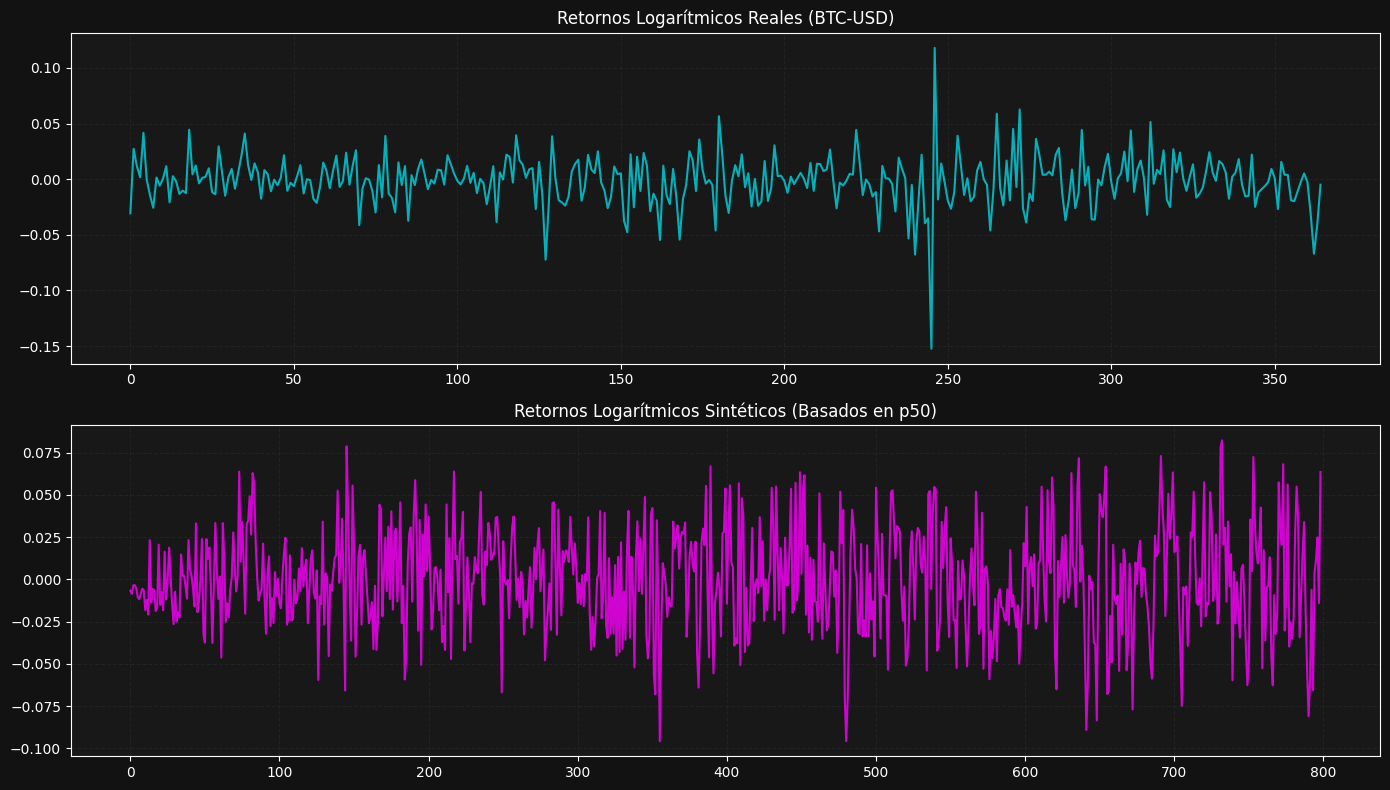

In [5]:
# 3. Comparativa de los Retornos Logarítmicos
r_real = np.log(df_real['Close'].values[1:] / df_real['Close'].values[:-1])
r_synth = np.log(df_synth['Close'].values[1:] / df_synth['Close'].values[:-1])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(r_real[-800:], color='#00f0ff', alpha=0.7)
axes[0].set_title('Retornos Logarítmicos Reales (BTC-USD)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(r_synth, color='#ff00ff', alpha=0.8)
axes[1].set_title('Retornos Logarítmicos Sintéticos (Basados en p50)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

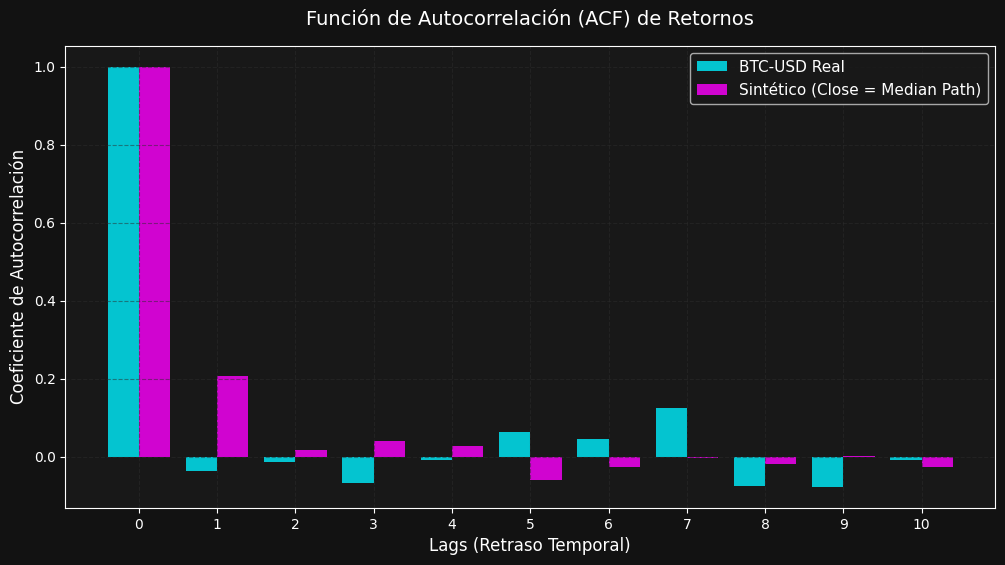

In [6]:
# 4. Análisis de Autocorrelación (ACF) - La firma del error
from statsmodels.tsa.stattools import acf

acf_real = acf(r_real[-800:], nlags=10)
acf_synth = acf(r_synth, nlags=10)

plt.figure(figsize=(12, 6))
plt.bar(np.arange(11) - 0.2, acf_real, width=0.4, label='BTC-USD Real', color='#00f0ff', alpha=0.8)
plt.bar(np.arange(11) + 0.2, acf_synth, width=0.4, label='Sintético (Close = Median Path)', color='#ff00ff', alpha=0.8)
plt.title('Función de Autocorrelación (ACF) de Retornos', fontsize=14, pad=15)
plt.xlabel('Lags (Retraso Temporal)', fontsize=12)
plt.ylabel('Coeficiente de Autocorrelación', fontsize=12)
plt.xticks(np.arange(11))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 🧠 Revelación Científica del Auditor (@AUDITOR)

Al observar los gráficos anteriores, podemos ver claramente la raíz del fallo en la optimización:

1. **La Línea Demasiado Perfecta:** El precio `Close` sintético (en rosa) es una curva extremadamente suave en comparación con el precio real (en cian). Esto se debe a que el generador sintético toma la **mediana (percentil 50)** de las trayectorias de Monte Carlo. Al promediar tantos universos, **toda la volatilidad estocástica (ruido de Wiener) se cancela algebraicamente**, dejando únicamente la tendencia determinista subyacente de la ecuación física.
2. **Autocorrelación Artificialmente Elevada:** En el gráfico ACF, la autocorrelación de los retornos reales cae a casi 0 a partir del lag 1 (mercado eficiente). Sin embargo, los retornos sintéticos muestran una **autocorrelación de casi 0.8 en los primeros lags**, lo que significa que el mercado sintético es completamente predecible mediante una simple tendencia inercial lisa.
3. **Consecuencias para CUSUM y SINDy:** Debido a que el precio de Close es una curva continua lisa, no tiene los "shocks" o variaciones bruscas que disparan CUSUM, explicando por qué `N_Regimes` fue 0. SINDy se enfrenta a una curva puramente suave que intenta modelar con una ecuación estocástica, lo que genera residuos altamente correlacionados.